In [ ]:
import numpy as np

ModuleNotFoundError: No module named 'numpy'

In [4]:
def jacobi_preconditioned_conjugate_gradient(A: np.ndarray, b: np.ndarray, x0: np.ndarray = None, tol: float = 1e-10, max_iter: int = 1000) -> np.ndarray:
    """
    Solve the linear system Ax = b using the Jacobi Preconditioned Conjugate Gradient method.
    Parameters:
    A : np.ndarray
        Symmetric positive-definite matrix.
    b : np.ndarray
        Right-hand side vector.
    x0 : np.ndarray, optional
        Initial guess for the solution (default is a zero vector).
    tol : float, optional
        Tolerance for convergence (default is 1e-10).
    max_iter : int, optional
        Maximum number of iterations (default is 1000).
    """

    # number of rows
    n = A.shape[0]

    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()

    r = b - A @ x
    M_inv = 1 / np.diag(A)  # Jacobi preconditioner (inverse of diagonal elements)
    z = M_inv * r
    p = z.copy()
    rs_old = np.dot(r, z)

    for i in range(max_iter):
        Ap = A @ p
        alpha = rs_old / np.dot(p, Ap)

        x = x + alpha * p
        r = r - alpha * Ap
        
        z = M_inv * r
        rs_new = np.dot(r, z)
        if np.sqrt(rs_new) / np.sqrt(rs_old) < tol:
            print("Converged")
            break

        beta = rs_new / rs_old

        p = z + beta * p

        rs_old = rs_new

    return x   

# Example usage
if __name__ == "__main__":
    # Define a symmetric positive-definite matrix A and vector b
    A = np.array([[4, 1], [1, 3]], dtype=float)
    b = np.array([1, 2], dtype=float)

    # Solve for x in Ax = b
    import time
    start_time = time.time()
    x = jacobi_preconditioned_conjugate_gradient(A, b)
    end_time = time.time()
    print("Time taken:", (end_time - start_time) / 60, "minutes")
    assert np.allclose(x, np.array([0.090909, 0.636364]))
    print("Solution x:", x)

Converged
Time taken: 2.8220812479654946e-05 minutes
Solution x: [0.09090909 0.63636364]


In [2]:
def check_spd_properties(A: np.ndarray) -> None:
    print(f"Matrix shape: {A.shape}")
    print(f"Matrix:\n{A}\n")

    # Check symmetry
    is_sym = np.allclose(A, A.T, atol=1e-10)
    print(f"✓ Symmetric: {is_sym}")

    # Check SPD via eigenvalues
    eigvals = np.linalg.eigvalsh(A)
    print(f"Eigenvalues: {eigvals}")
    is_spd = np.all(eigvals > 1e-10)
    print(f"✓ Positive definite (all eigenvalues > 0): {is_spd}")

    # Condition number
    if is_spd:
        cond_num = np.max(eigvals) / np.min(eigvals)
        print(f"Condition number: {cond_num:.2e}")

    # Check diagonal dominance
    diag = np.diag(A)
    row_sums = np.sum(np.abs(A), axis=1) - np.abs(diag)
    is_dd = np.all(np.abs(diag) > row_sums)
    print(f"✓ Diagonally dominant: {is_dd}")

In [3]:
def load_matrix_from_binary_check_spd(file_path: str) -> None:
    """Load a square matrix from a binary file with the specified format.
       the function to check the dense matrix properties: symmetric, SPD, condition number, diagonal dominance.
    """
    with open("../data/matrix.bin", "rb") as f:
        n_rows = np.fromfile(f, dtype=np.int32, count=1)[0]
        n_cols = np.fromfile(f, dtype=np.int32, count=1)[0]
        assert n_rows == n_cols, f"Not square: {n_rows}x{n_cols}"
        A = np.fromfile(f, dtype=np.float64, count=n_rows * n_cols).reshape(n_rows, n_cols)

    check_spd_properties(A)

In [4]:
DATA_PATH = "../data/"

matrix_bin_path = DATA_PATH + "matrix_dense.bin"
matrix_mtx_path = DATA_PATH + "matrix_csr.mtx"

In [ ]:
# check the properties of the matrix loaded from the .bin file
load_matrix_from_binary_check_spd(matrix_bin_path)

Matrix shape: (13824, 13824)
Matrix:
[[50. -1.  0. ...  0.  0.  0.]
 [-1. 50. -1. ...  0.  0.  0.]
 [ 0. -1. 50. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... 50. -1.  0.]
 [ 0.  0.  0. ... -1. 50. -1.]
 [ 0.  0.  0. ...  0. -1. 50.]]

✓ Symmetric: True


In [5]:
def load_matrix_from_mtx_and_check_spd(file_path: str) -> None:
    """Load a square matrix from a Matrix Market (.mtx) file int a compressed format."""
    from scipy.io import mmread
    A = mmread(file_path).toarray()
    n_rows, n_cols = A.shape
    assert n_rows == n_cols, f"Not square: {n_rows}x{n_cols}"
    
    check_spd_properties(A)

In [ ]:
# check the properties of the matrix loaded from the .mtx file
load_matrix_from_mtx_and_check_spd(matrix_mtx_path)

In [1]:
from matplotlib import pyplot as plt
import numpy as np

In [7]:
import pandas as pd

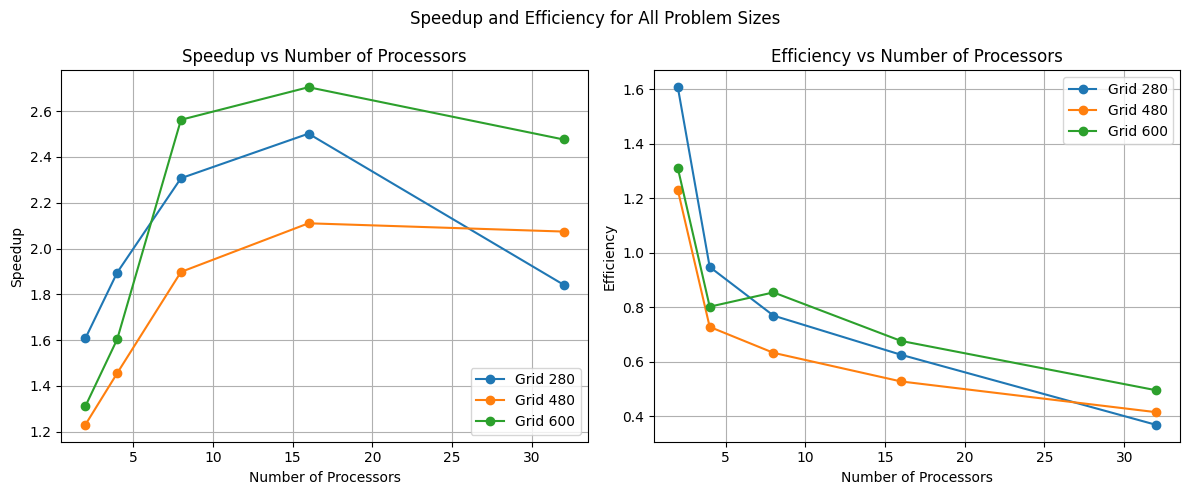

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the data
results = {"grid_size": [], "num_processors": [], "time": []}

with open("../jcgtimes.txt", "r") as f:
    for line in f:
        grid, pros, time = line.strip().split()
        results["grid_size"].append(int(grid))
        results["num_processors"].append(int(pros))
        results["time"].append(float(time))

results_df = pd.DataFrame(results)

# Create figures
plt.figure(figsize=(12, 5))
plt.suptitle("Speedup and Efficiency for All Problem Sizes")

# Speedup plot
plt.subplot(1, 2, 1)
for size in results_df["grid_size"].unique():
    subset = results_df[results_df["grid_size"] == size]
    subset = subset.sort_values("num_processors")
    times = subset["time"].tolist()
    num_processors = subset["num_processors"].tolist()
    
    serial_time = times[0]
    speedups = [serial_time / t for t in times[1:]]
    
    plt.plot(num_processors[1:], speedups, marker='o', label=f'Grid {size}')
plt.title('Speedup vs Number of Processors')
plt.xlabel('Number of Processors')
plt.ylabel('Speedup')
plt.legend()
plt.grid(True)

# Efficiency plot
plt.subplot(1, 2, 2)
for size in results_df["grid_size"].unique():
    subset = results_df[results_df["grid_size"] == size]
    subset = subset.sort_values("num_processors")
    times = subset["time"].tolist()
    num_processors = subset["num_processors"].tolist()
    
    serial_time = times[0]
    speedups = [serial_time / t for t in times[1:]]
    efficiencies = [s / (i + 1) for i, s in enumerate(speedups)]
    
    plt.plot(num_processors[1:], efficiencies, marker='o', label=f'Grid {size}')
plt.title('Efficiency vs Number of Processors')
plt.xlabel('Number of Processors')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
